![Alt text](https://imgur.com/orZWHly.png=80)
source: @allison_horst https://github.com/allisonhorst/penguins

You have been asked to support a team of researchers who have been collecting data about penguins in Antartica! The data is available in csv-Format as `penguins.csv`

**Origin of this data** : Data were collected and made available by Dr. Kristen Gorman and the Palmer Station, Antarctica LTER, a member of the Long Term Ecological Research Network.

**The dataset consists of 5 columns.**

Column | Description
--- | ---
culmen_length_mm | culmen length (mm)
culmen_depth_mm | culmen depth (mm)
flipper_length_mm | flipper length (mm)
body_mass_g | body mass (g)
sex | penguin sex

Unfortunately, they have not been able to record the species of penguin, but they know that there are **at least three** species that are native to the region: **Adelie**, **Chinstrap**, and **Gentoo**.  Your task is to apply your data science skills to help them identify groups in the dataset!

In [2]:
# Import Required Packages
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Loading and examining the dataset
penguins_df = pd.read_csv("penguins.csv")
penguins_df.head()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,39.1,18.7,181.0,3750.0,MALE
1,39.5,17.4,186.0,3800.0,FEMALE
2,40.3,18.0,195.0,3250.0,FEMALE
3,36.7,19.3,193.0,3450.0,FEMALE
4,39.3,20.6,190.0,3650.0,MALE


In [5]:
# Step 0: Investigation

print(penguins_df.shape)          # How many rows and columns?
print(penguins_df.dtypes)         # What type of data is in each column?
print(penguins_df.isnull().sum()) # Are there any missing values?
print(penguins_df.describe())     # Quick stats: min, max, mean, etc.

(332, 5)
culmen_length_mm     float64
culmen_depth_mm      float64
flipper_length_mm    float64
body_mass_g          float64
sex                   object
dtype: object
culmen_length_mm     0
culmen_depth_mm      0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64
       culmen_length_mm  culmen_depth_mm  flipper_length_mm  body_mass_g
count        332.000000       332.000000         332.000000   332.000000
mean          44.021084        17.153012         200.975904  4206.475904
std            5.452462         1.960275          14.035971   806.361278
min           32.100000        13.100000         172.000000  2700.000000
25%           39.500000        15.600000         190.000000  3550.000000
50%           44.700000        17.300000         197.000000  4025.000000
75%           48.625000        18.700000         213.000000  4781.250000
max           59.600000        21.500000         231.000000  6300.000000


In [8]:
# STEP 1 — Create dummy variables for the categorical column
df = pd.get_dummies(penguins_df, columns=['sex'], drop_first=False)
df_original = df.copy()
df_original.head()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex_FEMALE,sex_MALE
0,39.1,18.7,181.0,3750.0,0,1
1,39.5,17.4,186.0,3800.0,1,0
2,40.3,18.0,195.0,3250.0,1,0
3,36.7,19.3,193.0,3450.0,1,0
4,39.3,20.6,190.0,3650.0,0,1


In [11]:
# standardizing/scaling before clustering
scaler = StandardScaler()
scaled = scaler.fit_transform(df_original)
df_scaled = pd.DataFrame(scaled, columns=df.columns)
df_scaled

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex_FEMALE,sex_MALE
0,-0.903906,0.790360,-1.425342,-0.566948,-0.993994,0.993994
1,-0.830434,0.126187,-1.068577,-0.504847,1.006042,-1.006042
2,-0.683490,0.432728,-0.426399,-1.187953,1.006042,-1.006042
3,-1.344738,1.096901,-0.569105,-0.939551,1.006042,-1.006042
4,-0.867170,1.761074,-0.783164,-0.691149,-0.993994,0.993994
...,...,...,...,...,...,...
327,0.583904,-1.764152,0.929309,0.892415,1.006042,-1.006042
328,0.510432,-1.457611,1.000662,0.799264,1.006042,-1.006042
329,1.171681,-0.742347,1.500134,1.917074,-0.993994,0.993994
330,0.216543,-1.202160,0.786603,1.233968,1.006042,-1.006042


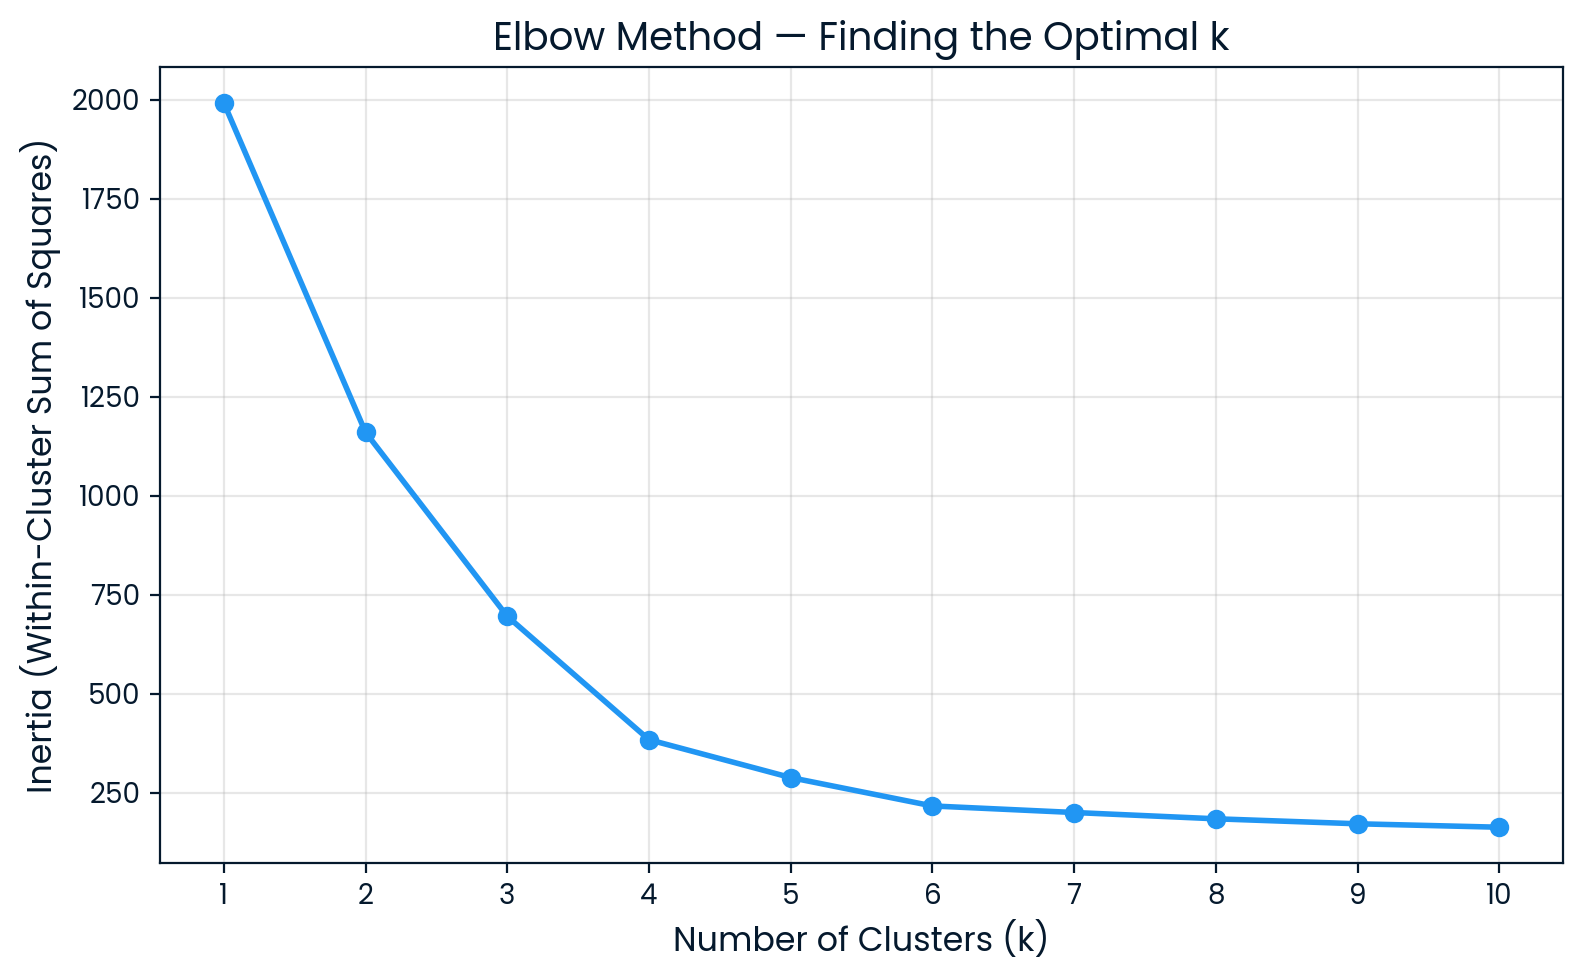

  k= 1  →  Inertia = 1992.00
  k= 2  →  Inertia = 1159.96
  k= 3  →  Inertia = 695.20
  k= 4  →  Inertia = 383.46
  k= 5  →  Inertia = 287.75
  k= 6  →  Inertia = 216.07
  k= 7  →  Inertia = 199.53
  k= 8  →  Inertia = 183.60
  k= 9  →  Inertia = 171.05
  k=10  →  Inertia = 162.33


In [19]:
# Detect the optimal number of clusters for k-means clustering
# Perform Elbow analysis
inertias = []
K_range = range(1,11)

for k in K_range:
    km=KMeans(n_clusters=k, random_state=42).fit(df_scaled)
    inertias.append(km.inertia_)

# Plot the Elbow curve
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, marker='o', linewidth=2, color='#2196F3')
plt.title('Elbow Method — Finding the Optimal k', fontsize=14)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12)
plt.xticks(list(K_range))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print inertias for reference
for k, inertia in zip(K_range, inertias):
    print(f"  k={k:2d}  →  Inertia = {inertia:.2f}")



=== Cluster counts (k=3) ===
0    107
1    119
2    106
Name: label, dtype: int64


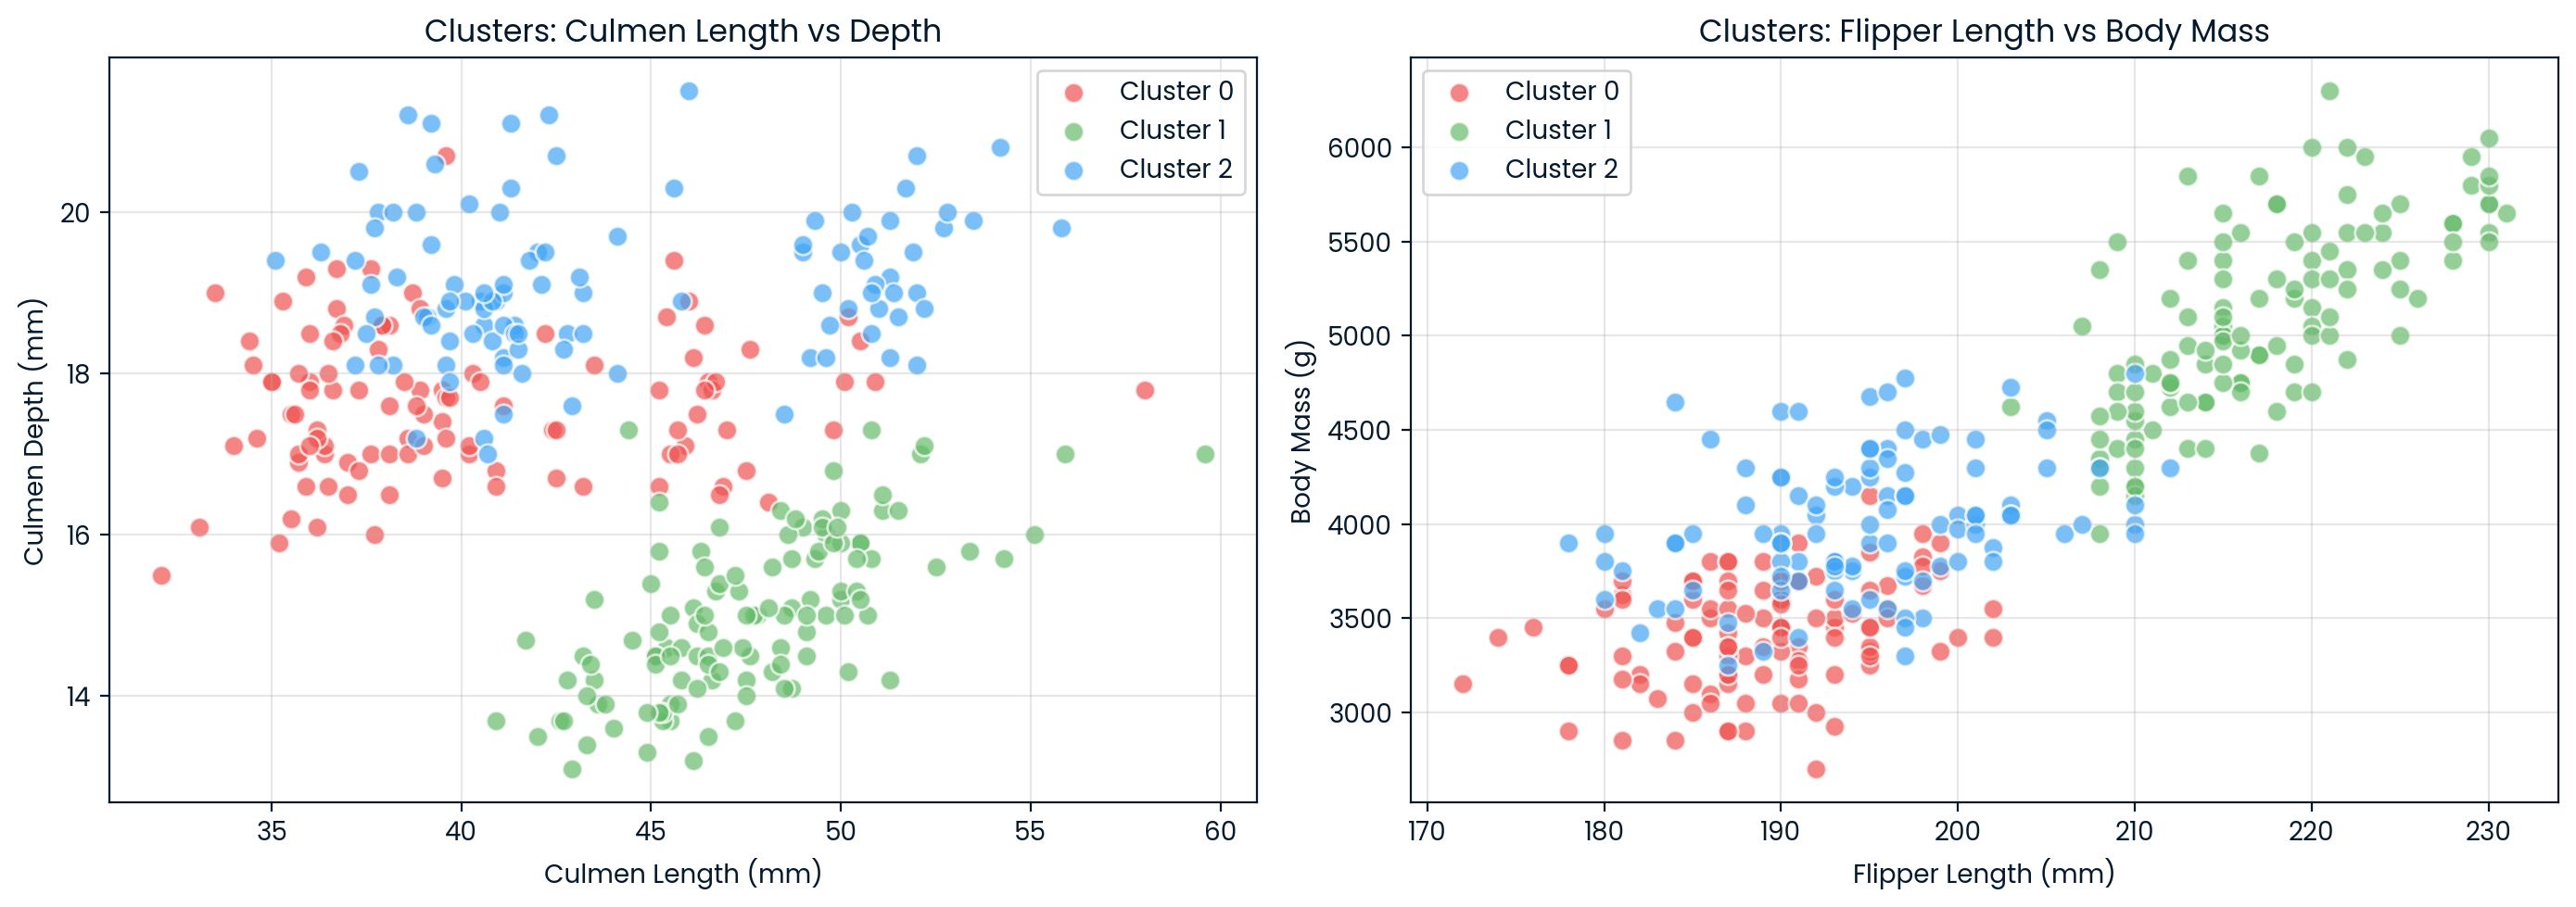

In [20]:
# STEP 3 — Run K-Means with optimal k = 3

optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
df_original["label"] = kmeans.fit_predict(df_scaled)

print(f"\n=== Cluster counts (k={optimal_k}) ===")
print(df_original['label'].value_counts().sort_index())
 
# Visualise clusters using the two most informative features
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#EF5350', '#66BB6A', '#42A5F5']
 
for cluster in range(optimal_k):
    mask = df_original['label'] == cluster
    axes[0].scatter(df_original.loc[mask, 'culmen_length_mm'],
                    df_original.loc[mask, 'culmen_depth_mm'],
                    c=colors[cluster], label=f'Cluster {cluster}',
                    alpha=0.7, edgecolors='w', s=60)
axes[0].set_xlabel('Culmen Length (mm)')
axes[0].set_ylabel('Culmen Depth (mm)')
axes[0].set_title('Clusters: Culmen Length vs Depth')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
 
for cluster in range(optimal_k):
    mask = df_original['label'] == cluster
    axes[1].scatter(df_original.loc[mask, 'flipper_length_mm'],
                    df_original.loc[mask, 'body_mass_g'],
                    c=colors[cluster], label=f'Cluster {cluster}',
                    alpha=0.7, edgecolors='w', s=60)
axes[1].set_xlabel('Flipper Length (mm)')
axes[1].set_ylabel('Body Mass (g)')
axes[1].set_title('Clusters: Flipper Length vs Body Mass')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
 
plt.tight_layout()
plt.show()

In [21]:
# STEP 4 — Final statistical DataFrame: stat_penguins
# ============================================================
# Group by cluster label, compute mean of numeric columns only
stat_penguins = df_original.groupby('label').mean(numeric_only=True)
# Drop any non-numeric columns (there shouldn't be any, but just in case)
stat_penguins = stat_penguins.select_dtypes(include='number')
 
print("\n=== stat_penguins ===")
print(stat_penguins.to_string())


=== stat_penguins ===
       culmen_length_mm  culmen_depth_mm  flipper_length_mm  body_mass_g  sex_FEMALE  sex_MALE
label                                                                                         
0             40.217757        17.611215         189.046729  3419.158879    1.000000  0.000000
1             47.568067        14.996639         217.235294  5092.436975    0.487395  0.512605
2             43.878302        19.111321         194.764151  4006.603774    0.000000  1.000000
